In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('phase3_model_data.csv')

In [3]:
cluster_features = [
    'Tenure',
    'SatisfactionScore',
    'OrderCount',
    'DaySinceLastOrder',
    'CashbackAmount',
    'NumberOfDeviceRegistered',
    'WarehouseToHome',
    'Complain'
]

X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertia = []
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

results = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertia,
    'silhouette': sil_scores
})

results

,k,inertia,silhouette
0,2,37250.379226,0.206714
1,3,32961.666087,0.177468
2,4,30303.432403,0.180204
3,5,28075.981799,0.167257
4,6,26399.279460,0.141127
5,7,25102.208951,0.150553
6,8,24106.351782,0.133034


The table shows the highest silhouette score at k=2, with 0.2067. That gives the cleanest separation among the tested values.

what this means: 
    K = 2 gives the strongest statistical separation
    K = 3 gives more business detail if there is a need for richer segment stories
    K = 4 and abveo add complexity without imporving cluster quality much

For bettre business interpretability and segment actionability i will choose K = 3.

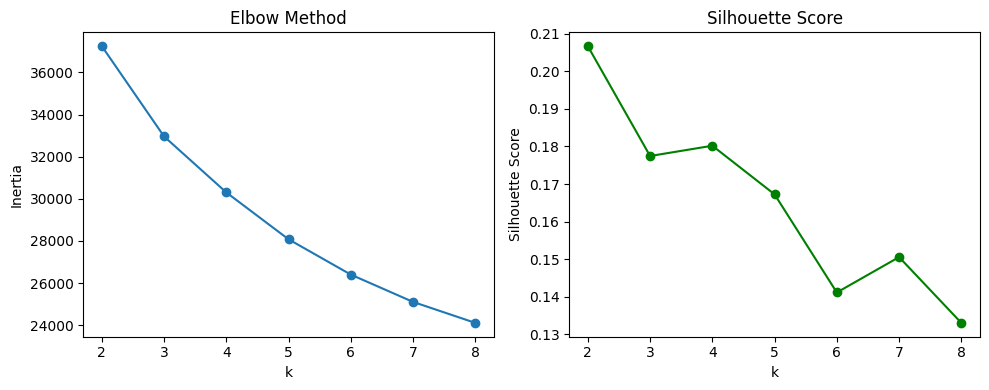

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o', color='green')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

In [5]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster')[cluster_features + ['Churn']].mean().round(2)
cluster_size = df['cluster'].value_counts().sort_index()

cluster_profile, cluster_size

(         Tenure  SatisfactionScore  OrderCount  DaySinceLastOrder  \
 cluster                                                             
 0          7.92               2.97        2.30               3.54   
 1         17.30               3.12        6.34               8.16   
 2          7.59               3.08        2.00               3.57   
 
          CashbackAmount  NumberOfDeviceRegistered  WarehouseToHome  Complain  \
 cluster                                                                        
 0                162.63                      3.66            16.10       1.0   
 1                236.94                      3.87            15.25       0.2   
 2                157.47                      3.63            15.66       0.0   
 
          Churn  
 cluster         
 0         0.36  
 1         0.08  
 2         0.12  ,
 cluster
 0    1335
 1    1313
 2    2982
 Name: count, dtype: int64)

    Inference

Cluster 0 is the highest risk segment. It has the highest churn rate at 0.36, the lowest satisfaction at 2.97, the highest complain rate at 1.0, and low order count at 2.30.

Cluster 1 is the healthiest segment. It has the lowest churn rate at 0.08, the longest tenure at 17.30, the highest order count at 6.34, the highest cashback amount at 236.94, and low complain rate at 0.2.

Cluster 2 sits in the middle. It has churn at 0.12, moderate satisfaction at 3.08, low complain rate at 0.0, and the largest customer base at 2,982 users.

    Business meaning
    
The pattern points to early lifecycle dissatisfaction as the main churn driver. Cluster 0 looks like new, unhappy customers who complain and do not order enough. Cluster 1 looks like loyal, high value customers with strong engagement. Cluster 2 looks like a stable base with moderate behavior and 
lower risk.

    Takeaway

Strongest retention target is cluster because they chorn far more than the other groups.

In [6]:
summary = df.groupby('cluster').agg(
    customers=('cluster', 'size'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('Tenure', 'mean'),
    avg_satisfaction=('SatisfactionScore', 'mean'),
    avg_order_count=('OrderCount', 'mean'),
    avg_days_since_last_order=('DaySinceLastOrder', 'mean')
).round(2)

summary

,customers,churn_rate,avg_tenure,avg_satisfaction,avg_order_count,avg_days_since_last_order
cluster,,,,,,
0,1335,0.36,7.92,2.97,2.30,3.54
1,1313,0.08,17.30,3.12,6.34,8.16
2,2982,0.12,7.59,3.08,2.00,3.57


    Inference
The biggest issue is not the whole base. It is a specific low tenure, low satisfaction, low order group with high complaints. That is your churn engine.

Cluster 0 is the highest risk segment with the highest churn rate at 36 percent, lowest satisfaction, and low order depth. This shows that early customer experience, complaint handling, and first repeat order conversion are the best retention levers.